In [5]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala.graph_color import vertex_color
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    find_kasteleyn_number,
    find_local_dimer_probability,
)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [20]:
n = 20
window = 0.4  # Width of the strip around the center

center = 0.5 + 1 / (4 * n)
lattice = eg.honeycomb_lattice(n)
edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

# kitaev edge labels
edge_angles = np.arctan2(*lattice.edges.vectors.T) % np.pi
_, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

# Create a mask for edges that are within the specified window around the center
mask = np.abs(edge_centers[:, 0] - center) < window
mask = mask * (edge_labels == 0)  # Only keep edges with label 0
l2 = expand_edges_to_squares(lattice, np.where(mask)[0])
l2 = gu.com_relaxation(l2)

# Find the vertex indices for v1 and list of v2 options
v1 = np.argmin(la.norm(l2.vertices.positions - np.array([center, 0.5]), axis=1))
distances = gu.distance_matrix(l2)[v1]
pos_messed = l2.vertices.positions + 10 * (1 - distances[:, None] % 2)
v2_options = [
    np.argmin(la.norm(pos_messed - np.array([(center - u) % 1, 0.5]), axis=1))
    for u in np.linspace(0, 0.5, 2 * n)
]
v2_options = np.unique(v2_options)
distances = distances[v2_options]

# Find the Kasteleyn probabilitiesfor the lattice
dimer_probs = find_local_dimer_probability(l2)

# find probabilities for monomers
monomer_probs = []
for v2 in v2_options:
    monomer_lattice = gu.remove_vertices(l2, [v1, v2])
    monomer_prob = find_kasteleyn_number(monomer_lattice, True)
    normalisation = find_kasteleyn_number(l2, True)
    p = (monomer_prob[0] / normalisation[0]) * 10 ** (
        monomer_prob[1] - normalisation[1]
    )
    monomer_probs.append(p)
monomer_probs = np.array(monomer_probs)

[0.27856111 0.30141975 0.3749506  ... 0.43624568 0.49706377 0.38949111]
2592


<Axes: >

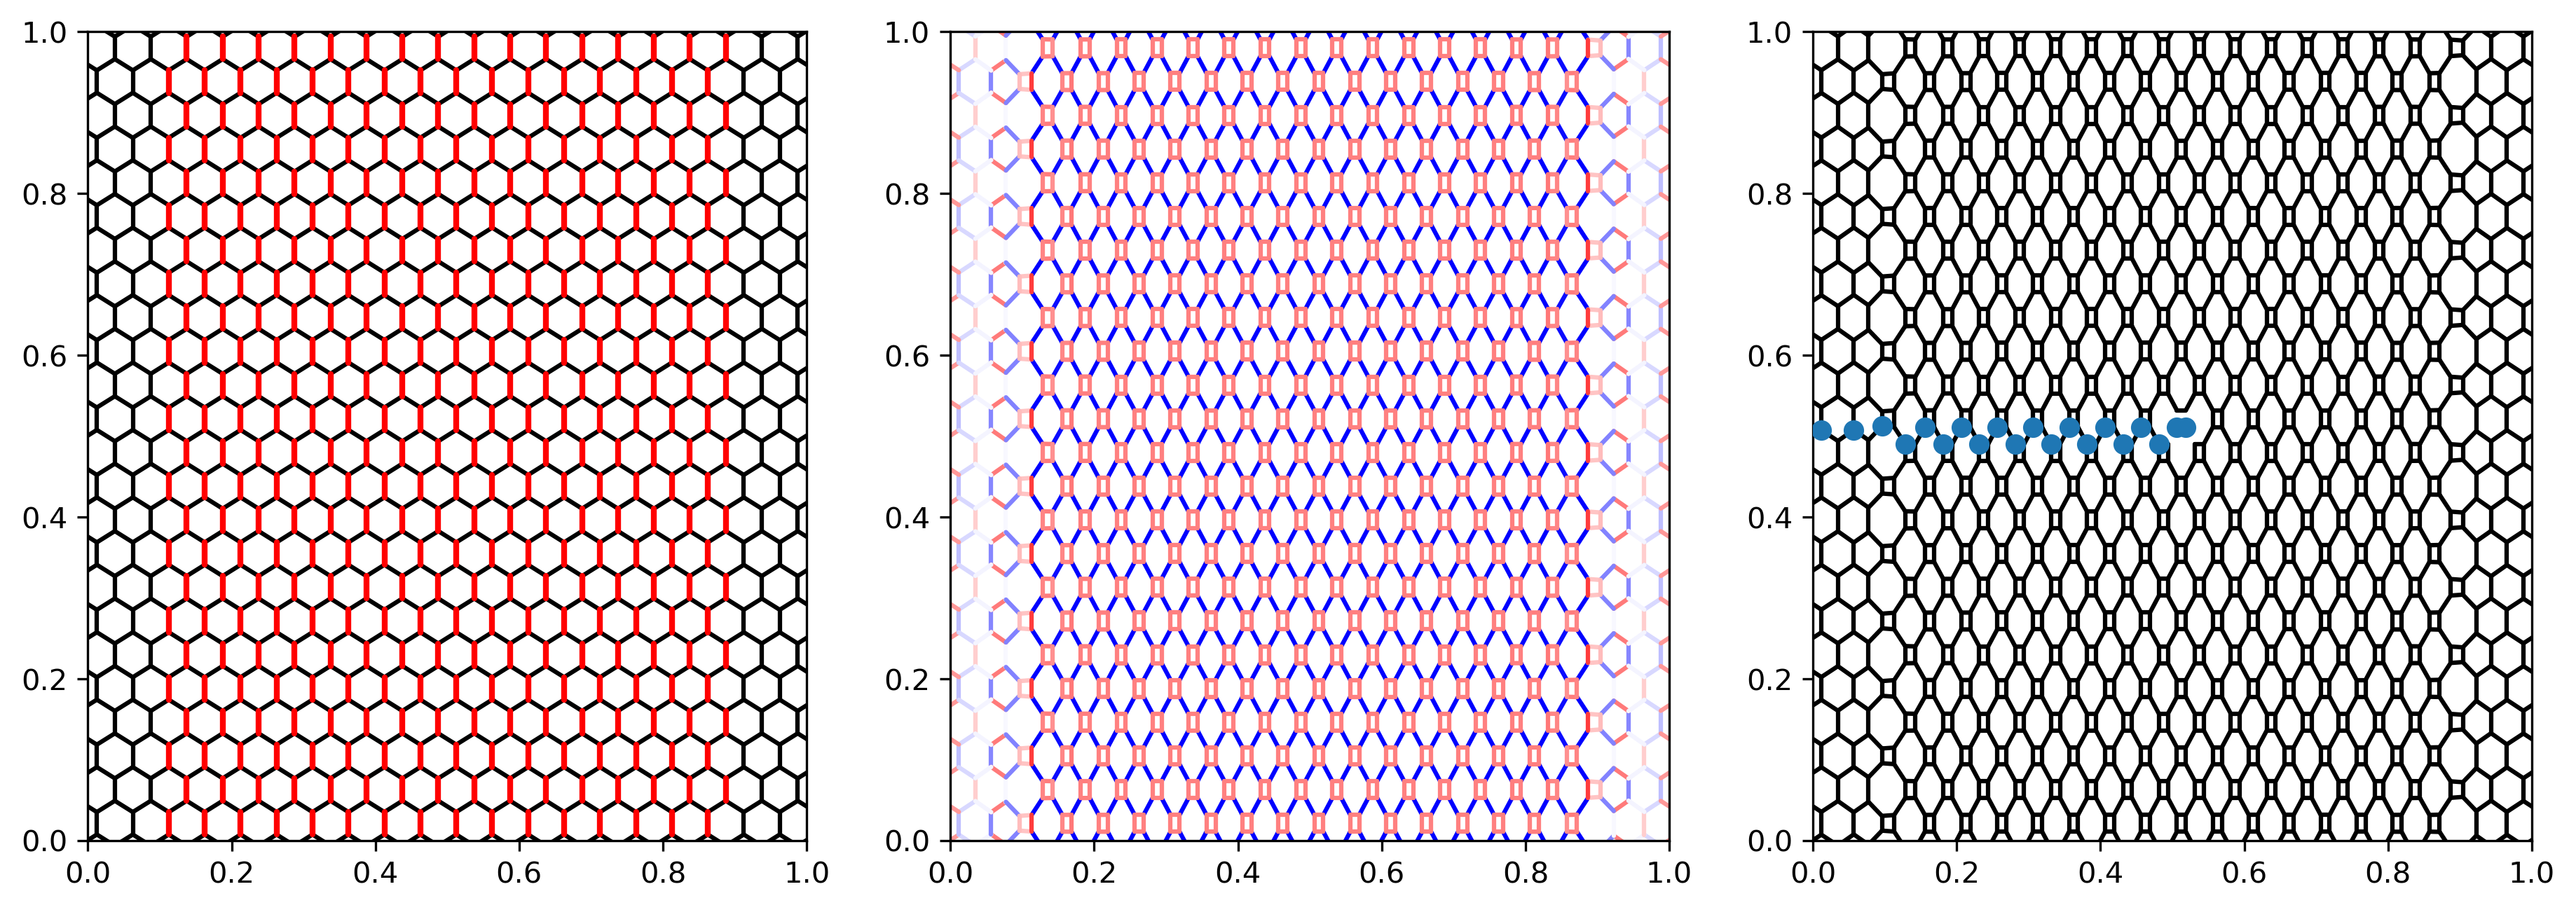

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(
    lattice,
    subset=np.where(mask),
    ax=ax[0],
    color_scheme=["r", "y", "b"],
    linewidth=2,
)

probs = dimer_probs - (1 / 3)
probs = (
    0.5 * probs / np.max([np.max(np.abs(probs)), 0.01])
)  # Normalize to range [-1, 1]
print(dimer_probs)

edge_labels = np.arange(l2.n_edges)
cmap = plt.get_cmap("bwr")
color_scheme = cmap(probs + 0.5)  # Shift to center around 0

print(len(color_scheme))

pl.plot_edges(
    l2,
    ax=ax[1],
    labels=edge_labels,
    color_scheme=color_scheme,
)

plt.scatter(*l2.vertices.positions[[v1, *v2_options]].T, zorder=10)


pl.plot_edges(
    monomer_lattice,
    ax=ax[2],
)